# EduInsight — Notebook 3: Exploratory Analysis

## Objective

Explore relationships between early student activity and later outcomes
without making causal claims.

In [1]:
from pathlib import Path
import sys


def locate_project_root(
    start: Path | None = None,
) -> Path:
    current = (
        start or Path.cwd()
    ).resolve()

    for candidate in (
        current,
        *current.parents,
    ):
        if (
            (candidate / "src").is_dir()
            and (
                candidate / "notebooks"
            ).is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Open VS Code from the repository "
        "folder and run the notebook again."
    )


PROJECT_ROOT = locate_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )


RAW_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)


SELECTED_MODULE = "BBB"
SELECTED_PRESENTATION = "2013J"
CUTOFF_DAY = 30


print(
    f"Project root: "
    f"{PROJECT_ROOT}"
)

Project root: D:\Work\GIT\eduinsight-student-success


## 1. Imports and processed-data loading

In [2]:
import matplotlib.pyplot as plt
import pandas as pd


processed_path = (
    PROCESSED_DATA_DIR
    / "student_features.csv"
)


if not processed_path.is_file():
    raise FileNotFoundError(
        "Processed data is missing. "
        "Run 02_data_preparation.ipynb first."
    )


data = pd.read_csv(
    processed_path
)


print(
    f"Rows: {len(data):,}"
)


data.head()

Rows: 1,825


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,total_clicks_30,active_days_30,unique_resources_30,avg_clicks_per_active_day_30,assessments_submitted_30,avg_score_30,late_submissions_30,has_early_assessment,support_needed
0,BBB,2013J,23798,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,...,-27.0,146,11,15,13.272727,1,90.0,0,1,0
1,BBB,2013J,27759,M,North Western Region,Lower Than A Level,40-50%,35-55,0,120,...,-43.0,123,12,21,10.250000,1,61.0,0,1,1
2,BBB,2013J,30091,F,South West Region,A Level or Equivalent,10-20,0-35,0,60,...,-145.0,162,8,22,20.250000,1,80.0,1,1,0
3,BBB,2013J,31014,F,West Midlands Region,Lower Than A Level,80-90%,35-55,0,120,...,-43.0,311,22,10,14.136364,1,85.0,0,1,1
4,BBB,2013J,31849,F,South West Region,Lower Than A Level,60-70%,35-55,0,120,...,-128.0,414,17,23,24.352941,1,81.0,0,1,0


## 2. Final-outcome distribution

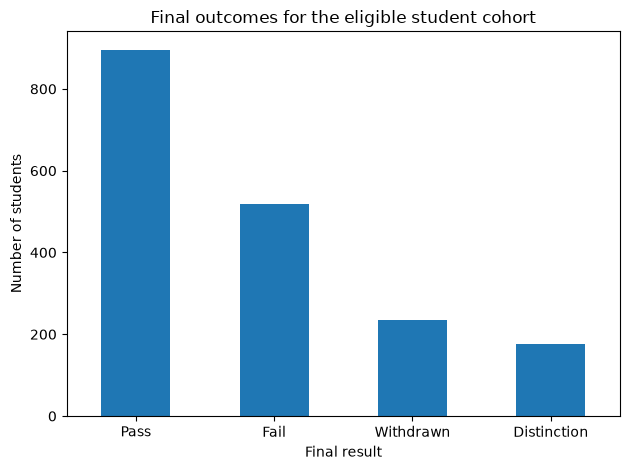

In [3]:
outcome_counts = (
    data[
        "final_result"
    ].value_counts()
)


outcome_counts.plot(
    kind="bar"
)


plt.title(
    "Final outcomes for the eligible student cohort"
)
plt.xlabel("Final result")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Chart Interpretation:** The classes are imbalanced: Pass is the largest, followed by Fail, while Withdrawn and Distinction are much smaller. Because of this, accuracy alone may be misleading, so evaluation should also use precision, recall, F1-score, and macro-averaged metrics.


## 3. Early clicks by outcome

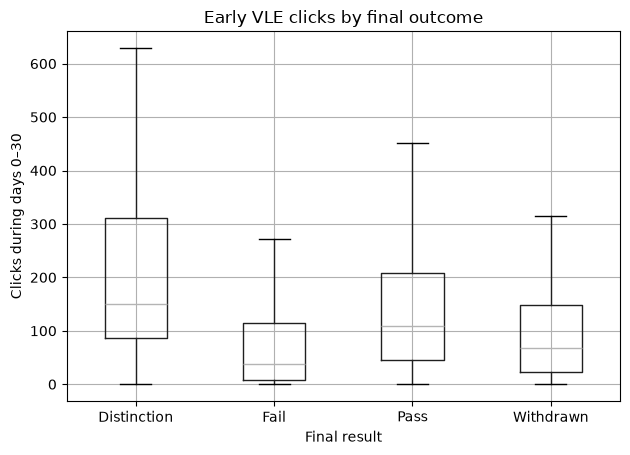

In [4]:
data.boxplot(
    column="total_clicks_30",
    by="final_result",
    showfliers=False,
)


plt.title(
    "Early VLE clicks by final outcome"
)
plt.suptitle("")
plt.xlabel("Final result")
plt.ylabel(
    "Clicks during days 0–30"
)
plt.tight_layout()
plt.show()

## 4. Active days by outcome

In [5]:
active_day_summary = (
    data
    .groupby(
        "final_result"
    )[
        "active_days_30"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
        ]
    )
    .round(2)
    .sort_values(
        "median",
        ascending=False,
    )
)


active_day_summary

,count,mean,median
final_result,,,
Distinction,175,13.23,12.0
Pass,896,10.18,8.0
Withdrawn,235,7.53,6.0
Fail,519,6.10,4.0


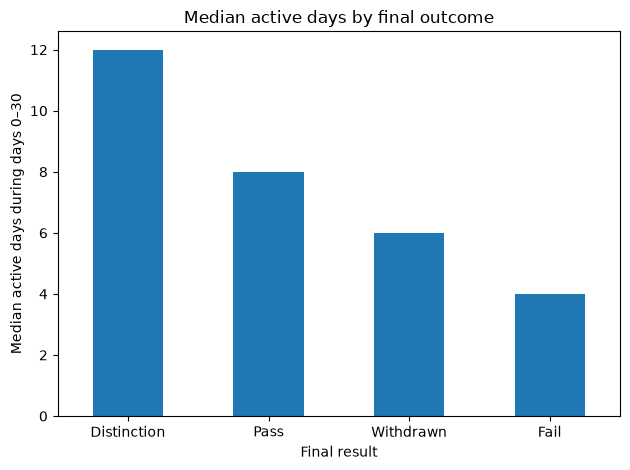

In [6]:
active_day_summary[
    "median"
].plot(
    kind="bar"
)


plt.title(
    "Median active days by final outcome"
)
plt.xlabel("Final result")
plt.ylabel(
    "Median active days during days 0–30"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Early assessment participation

In [7]:
assessment_summary = (
    data
    .groupby(
        "final_result"
    )[
        [
            "assessments_submitted_30",
            "avg_score_30",
            "late_submissions_30",
        ]
    ]
    .agg(
        [
            "mean",
            "median",
        ]
    )
    .round(2)
)


assessment_summary

assessments_submitted_30        avg_score_30         \
                                 mean median         mean median   
final_result                                                       
Distinction                      0.99    1.0        80.17   81.0   
Fail                             0.74    1.0        67.16   69.0   
Pass                             0.97    1.0        73.36   74.0   
Withdrawn                        0.77    1.0        69.77   70.5   

             late_submissions_30         
                            mean median  
final_result                             
Distinction                 0.02    0.0  
Fail                        0.11    0.0  
Pass                        0.05    0.0  
Withdrawn                   0.10    0.0

## 6. Relationship between early clicks and early scores

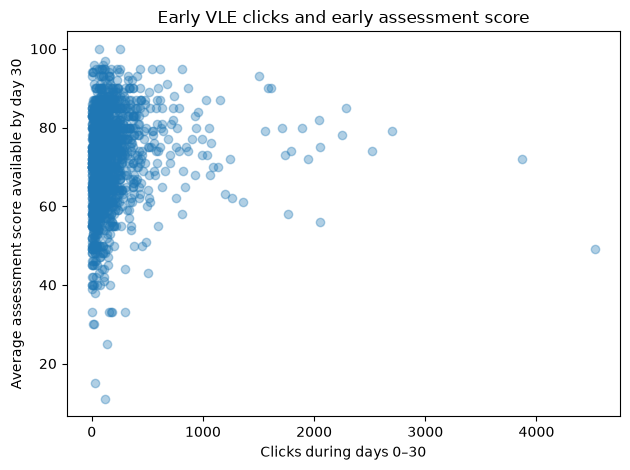

In [8]:
scored_students = (
    data.dropna(
        subset=[
            "avg_score_30"
        ]
    )
)


plt.scatter(
    scored_students[
        "total_clicks_30"
    ],
    scored_students[
        "avg_score_30"
    ],
    alpha=0.35,
)


plt.title(
    "Early VLE clicks and early assessment score"
)
plt.xlabel(
    "Clicks during days 0–30"
)
plt.ylabel(
    "Average assessment score available by day 30"
)
plt.tight_layout()
plt.show()

## 7. Numeric correlation review

In [9]:
numeric_columns = [
    "num_of_prev_attempts",
    "studied_credits",
    "date_registration",
    "total_clicks_30",
    "active_days_30",
    "unique_resources_30",
    "avg_clicks_per_active_day_30",
    "assessments_submitted_30",
    "avg_score_30",
    "late_submissions_30",
    "has_early_assessment",
    "support_needed",
]


correlation_matrix = (
    data[
        numeric_columns
    ]
    .corr(
        numeric_only=True
    )
    .round(2)
)


correlation_matrix

,num_of_prev_attempts,studied_credits,date_registration,total_clicks_30,active_days_30,unique_resources_30,avg_clicks_per_active_day_30,assessments_submitted_30,avg_score_30,late_submissions_30,has_early_assessment,support_needed
num_of_prev_attempts,1.00,-0.00,-0.04,-0.04,-0.09,-0.11,-0.05,-0.15,-0.06,0.03,-0.15,0.14
studied_credits,-0.00,1.00,-0.07,0.00,0.08,0.04,-0.04,-0.04,0.00,0.04,-0.04,0.10
date_registration,-0.04,-0.07,1.00,-0.04,-0.09,-0.02,-0.00,0.03,-0.05,0.05,0.03,0.00
total_clicks_30,-0.04,0.00,-0.04,1.00,0.66,0.56,0.82,0.18,0.11,-0.08,0.18,-0.17
active_days_30,-0.09,0.08,-0.09,0.66,1.00,0.65,0.46,0.36,0.22,-0.11,0.36,-0.28
unique_resources_30,-0.11,0.04,-0.02,0.56,0.65,1.00,0.62,0.36,0.13,-0.03,0.36,-0.21
avg_clicks_per_active_day_30,-0.05,-0.04,-0.00,0.82,0.46,0.62,1.00,0.21,0.11,-0.05,0.21,-0.16
assessments_submitted_30,-0.15,-0.04,0.03,0.18,0.36,0.36,0.21,1.00,-0.00,0.10,0.99,-0.33
avg_score_30,-0.06,0.00,-0.05,0.11,0.22,0.13,0.11,-0.00,1.00,-0.18,NaN,-0.26
late_submissions_30,0.03,0.04,0.05,-0.08,-0.11,-0.03,-0.05,0.10,-0.18,1.00,0.10,0.11


## 8. Findings and limitations

1. Students in the Pass and Distinction groups had a higher median number
   of active days than students in the Fail and Withdrawn groups.

2. The Withdrawn group showed lower early platform engagement in the
   selected course presentation.

3. Students with recorded early assessments had different outcome
   distributions from students without an early score.

4. Early activity variables are associated with final outcomes, but the
   analysis does not demonstrate that engagement directly causes success.